Part 1：Dataset Understanding

In [5]:
#1. Load datasets

import pandas as pd
sold = pd.read_csv("combined_sold_202401_202604_residential.csv")
listing = pd.read_csv("combined_listing_202401_202604_residential.csv")

#2. Dataset dimensions
print("=== SOLD ===")
print(f"Rows: {sold.shape[0]:,}")
print(f"Columns: {sold.shape[1]}")

print("\n=== LISTING ===")
print(f"Rows: {listing.shape[0]:,}")
print(f"Columns: {listing.shape[1]}")

#3. Preview the datasets
sold.head()
listing.head()

#4. Review column names
sold.columns
listing.columns

#5. Review data types
sold.info()
listing.info()


/var/folders/j5/58l4k_310d7g3m6jv7qw33z80000gn/T/ipykernel_1336/936596814.py:4: DtypeWarning: Columns (0,1,4,78,79,80) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("combined_sold_202401_202604_residential.csv")
/var/folders/j5/58l4k_310d7g3m6jv7qw33z80000gn/T/ipykernel_1336/936596814.py:5: DtypeWarning: Columns (43) have mixed types. Specify dtype option on import or set low_memory=False.
  listing = pd.read_csv("combined_listing_202401_202604_residential.csv")


=== SOLD ===
Rows: 350,179
Columns: 82

=== LISTING ===
Rows: 547,162
Columns: 84
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350179 entries, 0 to 350178
Data columns (total 82 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 299303 non-null  object 
 1   ListAgentAOR                  303996 non-null  object 
 2   Flooring                      224124 non-null  object 
 3   ViewYN                        320263 non-null  object 
 4   WaterfrontYN                  219 non-null     object 
 5   BasementYN                    6866 non-null    object 
 6   PoolPrivateYN                 321447 non-null  object 
 7   OriginalListPrice             349518 non-null  float64
 8   ListingKey                    350179 non-null  int64  
 9   ListAgentEmail                349228 non-null  object 
 10  CloseDate                     350179 non-null  object 
 11  ClosePrice            

Part2:Missing Value Analysis

In [6]:
#Step 1. Build Missing Value Summary
def missing_summary(df):

    summary = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": (df.isnull().mean() * 100).round(2)
    })

    return summary.sort_values("Missing %", ascending=False)

sold_missing = missing_summary(sold)
listing_missing = missing_summary(listing)
sold_missing.head(20)




,Missing Count,Missing %
BusinessType,350179,100.00
CoveredSpaces,350179,100.00
TaxAnnualAmount,350179,100.00
TaxYear,350179,100.00
ElementarySchoolDistrict,350179,100.00
FireplacesTotal,350179,100.00
AboveGradeFinishedArea,350179,100.00
MiddleOrJuniorSchoolDistrict,350179,100.00
WaterfrontYN,349960,99.94
BelowGradeFinishedArea,348084,99.40


In [7]:
#Step 2.  columns with >90% missing values
sold_high_missing = sold_missing[
    sold_missing["Missing %"] > 90
]

listing_high_missing = listing_missing[
    listing_missing["Missing %"] > 90
]
print(len(sold_high_missing))
sold_high_missing

15


,Missing Count,Missing %
BusinessType,350179,100.00
CoveredSpaces,350179,100.00
TaxAnnualAmount,350179,100.00
TaxYear,350179,100.00
ElementarySchoolDistrict,350179,100.00
FireplacesTotal,350179,100.00
AboveGradeFinishedArea,350179,100.00
MiddleOrJuniorSchoolDistrict,350179,100.00
WaterfrontYN,349960,99.94
BelowGradeFinishedArea,348084,99.40


In [8]:
#Step 3：Save report

sold_missing.to_csv(
    "sold_missing_summary.csv",
    index=True
)

listing_missing.to_csv(
    "listing_missing_summary.csv",
    index=True
)

Part 3: Numeric Distribution Review

In [9]:
# Step 1. Select key numeric columns
numeric_columns = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "DaysOnMarket",
    "YearBuilt"
]

In [10]:
# Step 2. Generate summary statistics
def numeric_summary(df, columns):

    summary = df[columns].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).T

    summary = summary.rename(columns={
        "50%": "median"
    })

    return summary

sold_numeric_summary = numeric_summary(sold, numeric_columns)
listing_numeric_summary = numeric_summary(listing, numeric_columns)
sold_numeric_summary

,count,mean,std,min,1%,5%,25%,median,75%,95%,99%,max
ClosePrice,350178.0,1.194841e+06,6.680568e+06,0.0,200000.0,339000.00,575000.00,820000.0000,1.295000e+06,2.840000e+06,5.552460e+06,9.895000e+08
ListPrice,350179.0,1.136737e+06,1.367875e+06,525.0,213431.2,345000.00,575000.00,809990.0000,1.288000e+06,2.850000e+06,5.700000e+06,1.375000e+08
OriginalListPrice,349518.0,1.229578e+06,7.158364e+06,0.0,210000.0,349900.00,585000.00,825000.0000,1.299000e+06,2.899000e+06,5.995000e+06,1.390000e+09
LivingArea,349984.0,1.910400e+03,2.878580e+04,0.0,604.0,840.00,1248.00,1643.0000,2.218000e+03,3.555000e+03,5.265170e+03,1.702132e+07
LotSizeAcres,323198.0,7.568601e+01,1.737567e+04,0.0,0.0,0.03,0.12,0.1667,2.755000e-01,2.893300e+00,1.088610e+01,7.810698e+06
BedroomsTotal,350169.0,3.200929e+00,1.068545e+00,0.0,1.0,2.00,3.00,3.0000,4.000000e+00,5.000000e+00,6.000000e+00,4.500000e+01
BathroomsTotalInteger,350123.0,2.535455e+00,1.141898e+00,0.0,1.0,1.00,2.00,2.0000,3.000000e+00,4.000000e+00,6.000000e+00,1.750000e+02
DaysOnMarket,350179.0,3.853759e+01,5.099523e+01,-288.0,0.0,1.00,8.00,19.0000,5.000000e+01,1.350000e+02,2.350000e+02,2.177000e+03
YearBuilt,349871.0,1.978619e+03,2.633015e+01,1776.0,1912.0,1930.00,1960.00,1979.0000,1.999000e+03,2.023000e+03,2.025000e+03,2.026000e+03


In [12]:
#Step 3. Distribution plot histogram and boxplot

import matplotlib.pyplot as plt

def plot_distribution(df, column):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    df[column].dropna().hist(
        bins=50,
        ax=axes[0]
    )

    axes[0].set_title(f"{column} Histogram")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")

    # Boxplot
    axes[1].boxplot(
        df[column].dropna(),
        vert=False
    )

    axes[1].set_title(f"{column} Boxplot")

    plt.tight_layout()
    plt.show()

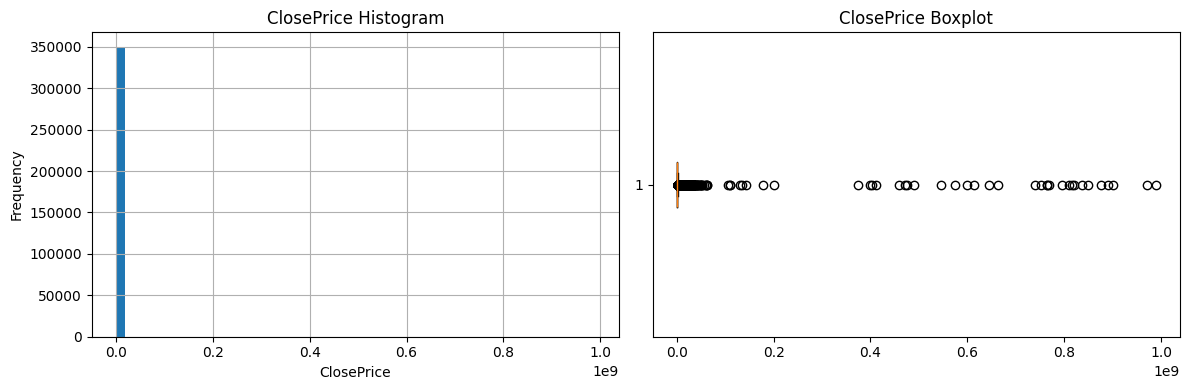

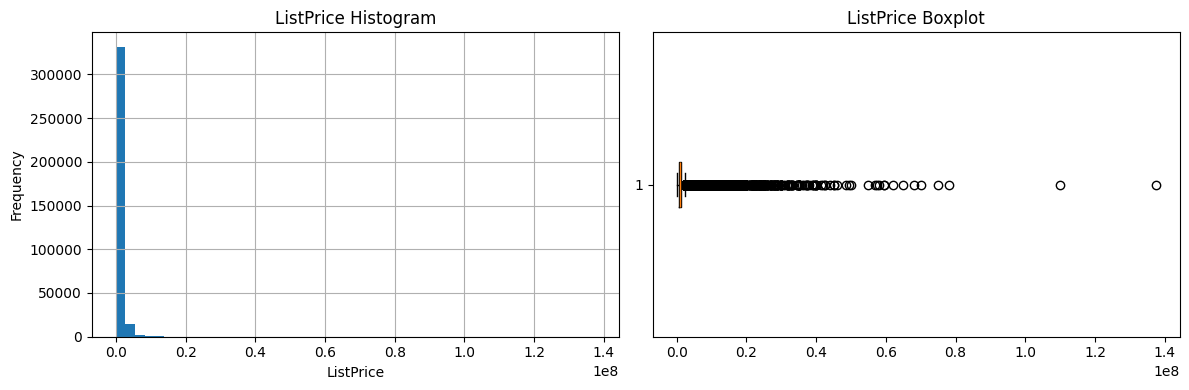

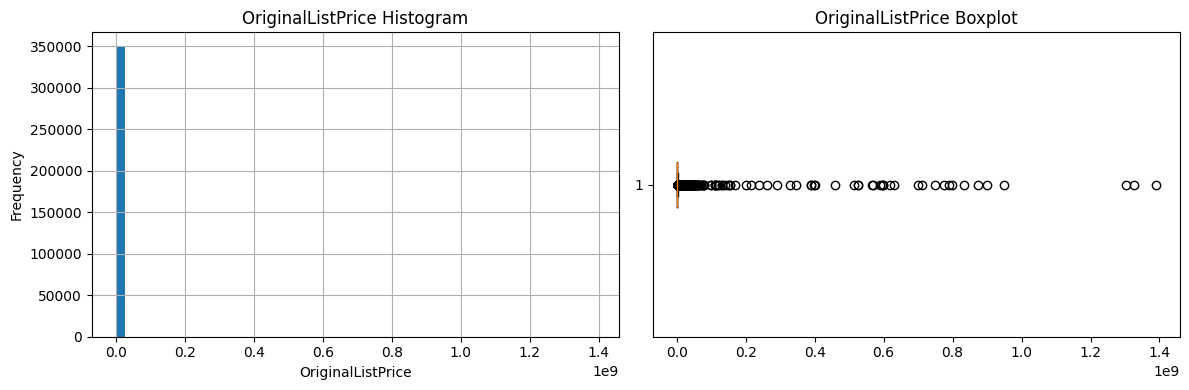

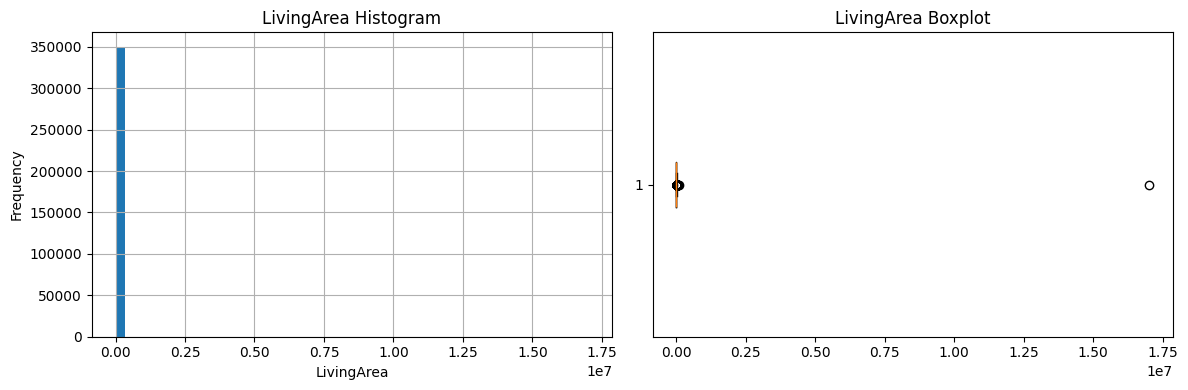

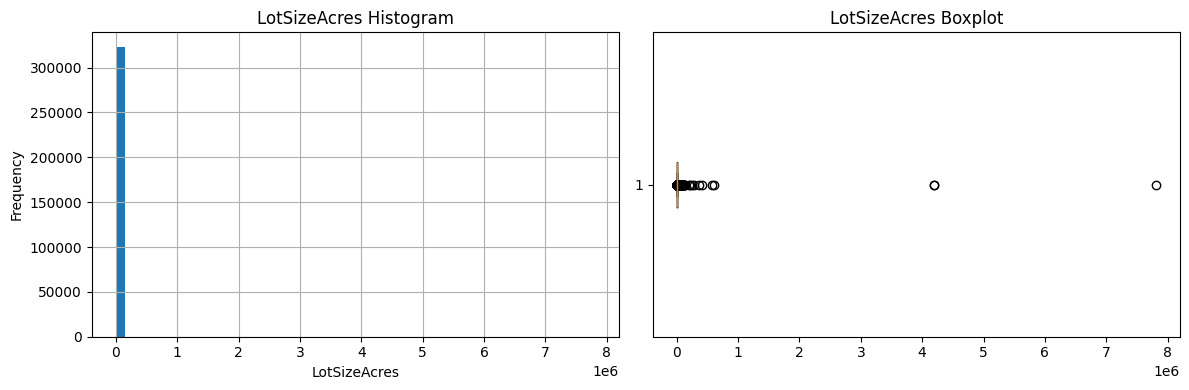

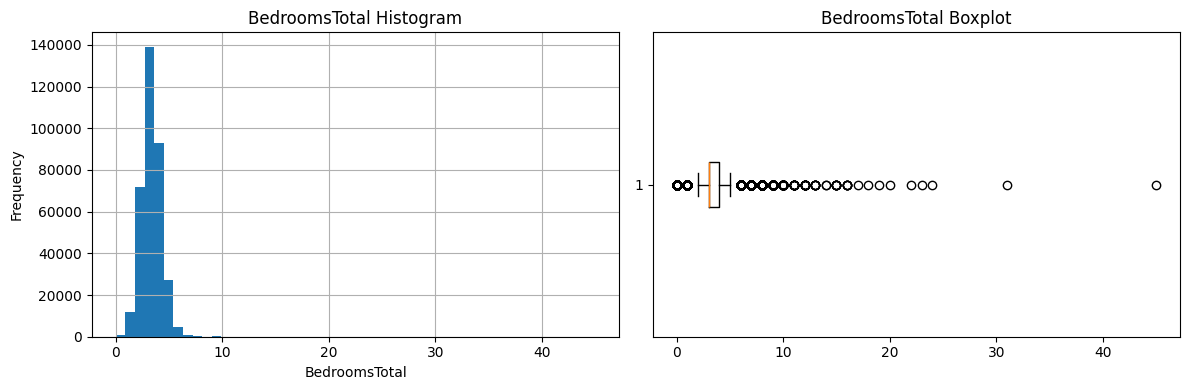

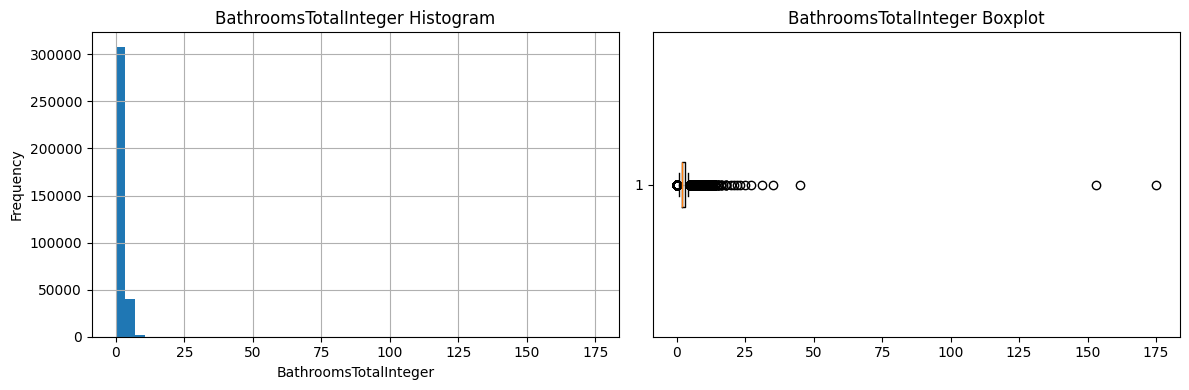

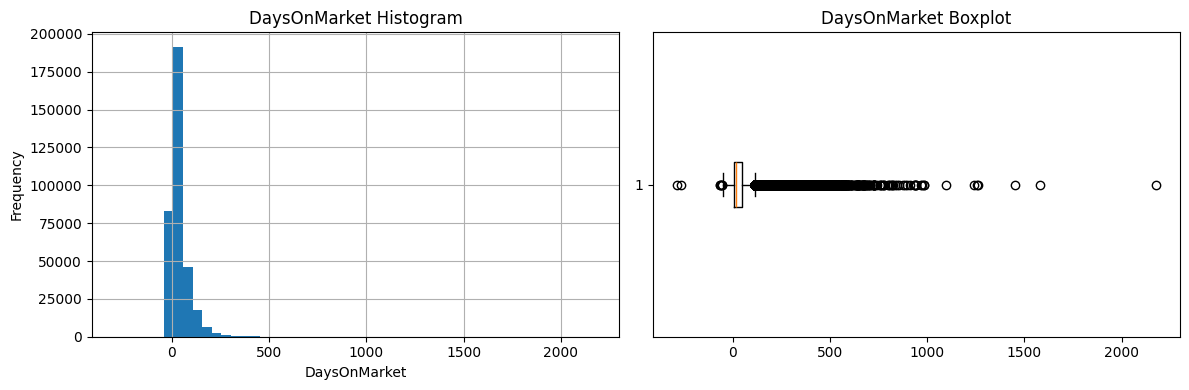

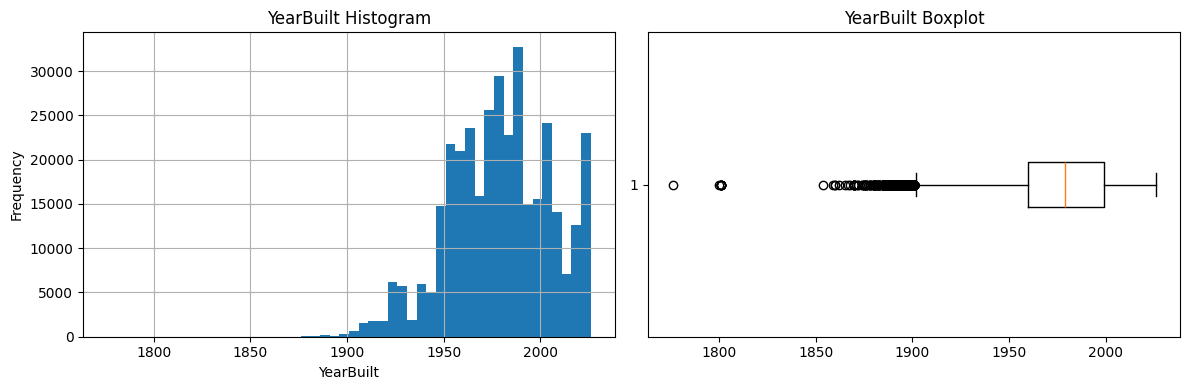

In [13]:
#Step 4. Plot all variables

for column in numeric_columns:
    plot_distribution(sold, column)

In [19]:
# Step 5. Identify extreme outliers using the IQR method
def outlier_summary(df, columns):

    results = []

    for column in columns:

        # Remove missing values
        data = df[column].dropna()

        # Calculate IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outlier_count = (
            (data < lower_bound) |
            (data > upper_bound)
        ).sum()

        results.append({
    "Column": column,
    "Count": len(data),
    "Q1": Q1,
    "Median": data.median(),
    "Q3": Q3,
    "IQR": IQR,
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound,
    "Outlier Count": outlier_count,
    "Outlier %": round(outlier_count / len(data) * 100, 2)
})

    return pd.DataFrame(results)

sold_outlier_summary = outlier_summary(

    sold,

    numeric_columns

)

listing_outlier_summary = outlier_summary(

    listing,

    numeric_columns

)

listing_outlier_summary

,Column,Count,Q1,Median,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,ClosePrice,137681,600000.00,850000.00,1.350000e+06,750000.0000,-525000.0000,2.475000e+06,9944,7.22
1,ListPrice,547162,583002.50,848994.50,1.385000e+06,801997.5000,-619993.7500,2.587996e+06,45935,8.40
2,OriginalListPrice,546373,585000.00,849000.00,1.395000e+06,810000.0000,-630000.0000,2.610000e+06,45037,8.24
3,LivingArea,546610,1248.00,1670.00,2.300000e+03,1052.0000,-330.0000,3.878000e+03,27011,4.94
4,LotSizeAcres,502132,0.12,0.17,3.122000e-01,0.1922,-0.1683,6.005000e-01,80487,16.03
5,BedroomsTotal,547029,2.00,3.00,4.000000e+00,2.0000,-1.0000,7.000000e+00,1751,0.32
6,BathroomsTotalInteger,547107,2.00,2.00,3.000000e+00,1.0000,0.5000,4.500000e+00,34529,6.31
7,DaysOnMarket,547162,5.00,10.00,2.100000e+01,16.0000,-19.0000,4.500000e+01,48732,8.91
8,YearBuilt,546235,1961.00,1980.00,2.001000e+03,40.0000,1901.0000,2.061000e+03,1382,0.25


In [20]:
sold_outlier_summary.to_csv(
    "sold_outlier_summary.csv",
    index=False
)

listing_outlier_summary.to_csv(
    "listing_outlier_summary.csv",
    index=False
)